In [5]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# SETUP & CONFIGURATION

In [6]:
seed=42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)

# Global constants
TEST_PATH = "/kaggle/input/datasets/nainidiwan23f3001480/smart-mcq-solver-challenge/test.csv"
TRAIN_PATH = "/kaggle/input/datasets/nainidiwan23f3001480/smart-mcq-solver-challenge/train.csv"
LABEL_MAP = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

# EDA

In [7]:
TRAIN_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

In [8]:
TRAIN_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [9]:
test_df.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [10]:
TRAIN_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


.describe(include='all') generates descriptive statistics. Using include='all' ensures it also summarizes object/string columns showing counts, unique values, and the most frequent value.

.info() prints a concise summary of the DataFrame, including the index dtype and columns, non-null values, and memory usage.


# DATA PREPROCESSING

## Check Null Values

In [11]:
mcq_cols = ['prompt', 'A', 'B', 'C', 'D', 'E']

TRAIN_df[mcq_cols].isna().sum()
#So there's no null value in this dataset

prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

## Drop rows with duplicate prompt

In [12]:
TRAIN_df['prompt'].duplicated().sum()

np.int64(242)

In [13]:
TRAIN_df[TRAIN_df['prompt'].duplicated(keep=False)].sort_values('prompt').head(3)

,id,prompt,A,B,C,D,E,answer
605,606,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E
456,457,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E
439,440,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E


Keep the first occurrence of each duplicate prompt and drops the rest:

In [14]:
TRAIN_df = TRAIN_df.drop_duplicates(subset='prompt', keep='first')
TRAIN_df['prompt'].duplicated().sum()  # should now be 0

np.int64(0)

## Case normalization - Convert all the text to lowercase

In [15]:
TRAIN_df[mcq_cols] = TRAIN_df[mcq_cols].apply(lambda col: col.str.lower())
test_df[mcq_cols] = test_df[mcq_cols].apply(lambda col: col.str.lower())

In [16]:
# Display an example
print(TRAIN_df['prompt'].iloc[0])

pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.


## Trip possible boiler plates

In [17]:
import re
def strip_boilerplate(text):
    return re.sub(r'^(pick the best possible answer|select the most accurate option|determine the correct option|choose the correct answer|identify the correct statement)\s*:\s*', '', text)

TRAIN_df['prompt'] = TRAIN_df['prompt'].apply(strip_boilerplate)
test_df['prompt'] = test_df['prompt'].apply(strip_boilerplate)

## Encode Options (answers)

In [18]:
encoder = LabelEncoder()
y = TRAIN_df['answer']
y = encoder.fit_transform(y)

In [19]:
TRAIN_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,what is martin heidegger's view on the relatio...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B
1,2,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,A
2,3,what is the term used in astrophysics to descr...,blueshifting,redshifting,reddening,whitening,yellowing,C
3,4,what is martin heidegger's view on the relatio...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B
4,5,what is the concept of simultaneity in einstei...,"simultaneity is relative, meaning that two eve...","simultaneity is relative, meaning that two eve...","simultaneity is absolute, meaning that two eve...",simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,A


# METRIC EVALUATION FUNCTION

It extracts logits (raw model predictions) and labels, and calculates standard Accuracy, Macro F1-score, and iteratively calculates the MAP@3 score.

In [20]:
def calculate_metrics(eval_preds):
    logits, labels = eval_preds
    preds = np.argsort(logits, axis=-1)[:, ::-1] # Sort in descending order

    top1_preds = preds[:, 0]
    accuracy = accuracy_score(labels, top1_preds)
    f1 = f1_score(labels, top1_preds, average="macro")

    map3_score = 0.0
    for i in range(len(labels)):
        true_label = labels[i]
        for rank in range(3):
            if preds[i, rank] == true_label:
                map3_score += 1.0 / (rank + 1)
                break
    map3_score /= len(labels)
    
    return {
        "accuracy": accuracy,
        "f1_score": f1,
        "map@3": map3_score
    }

`argsort` is chosen over `max` because we need to calculate Mean Average Precision at 3 (MAP@3) which requires top 3 rankings, not just the single best answer.

# Model-1: TF-IDF

`TfidfVectorizer` is chosen over `CountVectorizer` because it penalizes highly frequent, uninformative words. `cosine_similarity` is chosen over Euclidean distance because it measures the semantic direction of the text vectors, independent of their length.

In [22]:
X = TRAIN_df.iloc[:,1:7]
X.head()

,prompt,A,B,C,D,E
0,what is martin heidegger's view on the relatio...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...
1,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...
2,what is the term used in astrophysics to descr...,blueshifting,redshifting,reddening,whitening,yellowing
3,what is martin heidegger's view on the relatio...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...
4,what is the concept of simultaneity in einstei...,"simultaneity is relative, meaning that two eve...","simultaneity is relative, meaning that two eve...","simultaneity is absolute, meaning that two eve...",simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...


In [23]:
X.shape[0]

1758

In [24]:
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train_tfidf.shape[0]

1406

In [26]:
# Initialize vectorizer
vectorizer = TfidfVectorizer(max_df=0.95)
# Ignores words that appear in over 95% of the text (useless for discrimination)

# Fit vocabulary on all training text (prompt + all options), so every
# option and prompt share the same vector space
train_corpus = pd.concat([X_train_tfidf[col] for col in mcq_cols], ignore_index=True)
vectorizer.fit(train_corpus)

# Transform each column separately, for both train and val
X_train_vecs = {col: vectorizer.transform(X_train_tfidf[col]) for col in mcq_cols}
X_val_vecs = {col: vectorizer.transform(X_val_tfidf[col]) for col in mcq_cols}

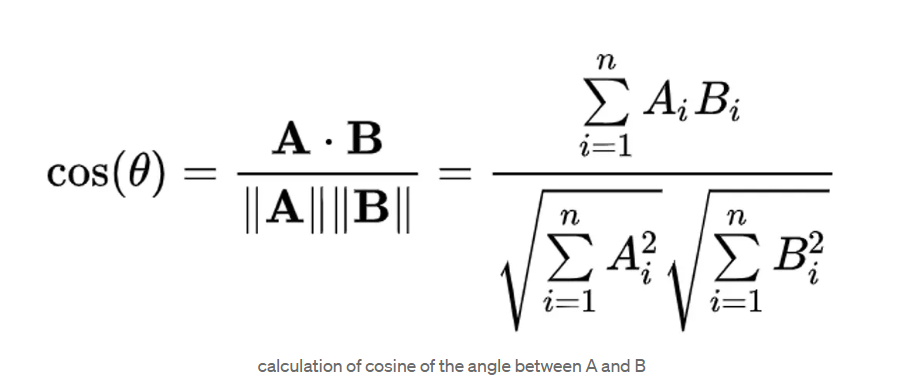
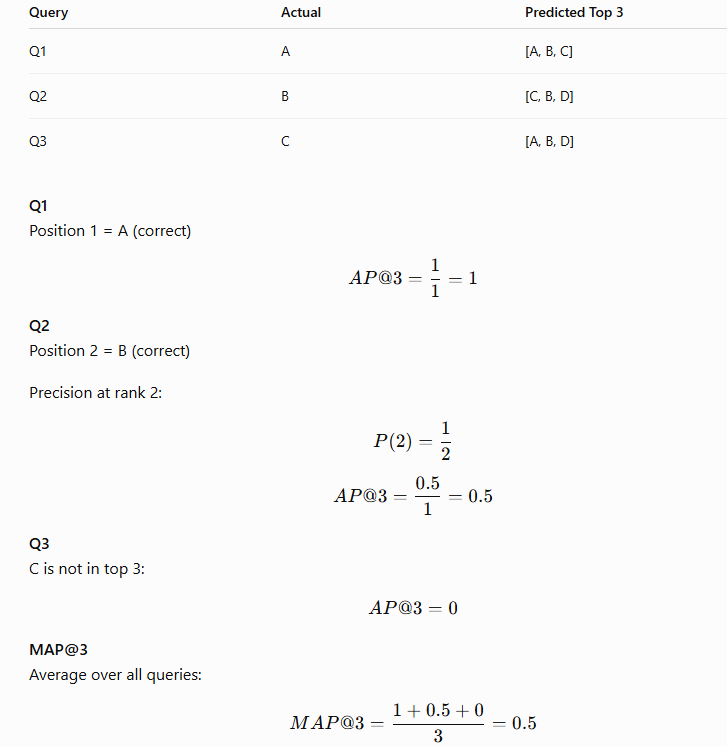
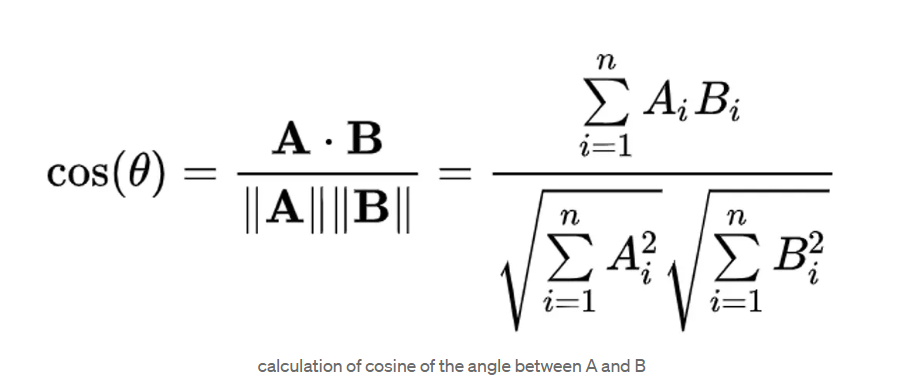
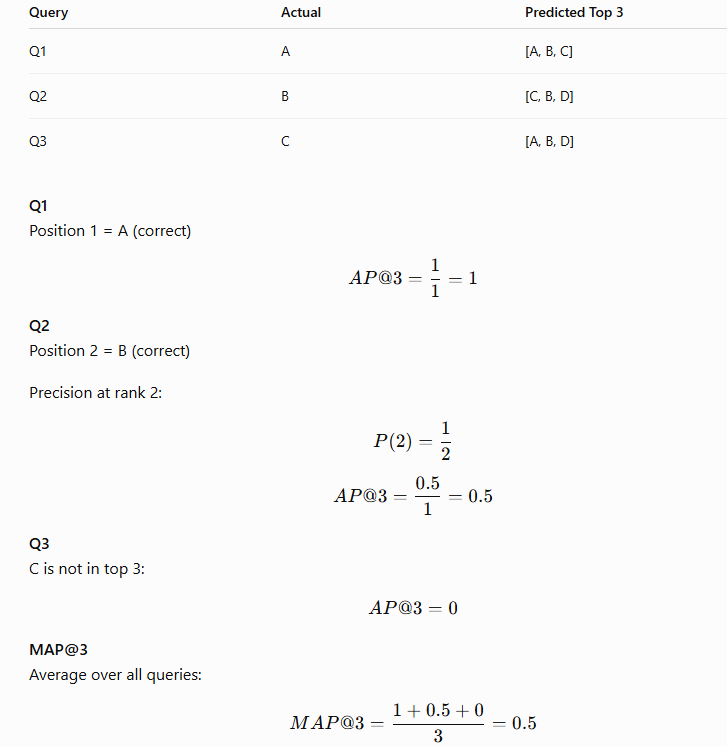

## Evaluate on validation data

In [27]:
# Cosine similarity between each option and its prompt, per row
option_cols = ['A', 'B', 'C', 'D', 'E']

sims = np.zeros((X_val_tfidf.shape[0], len(option_cols)))
for i, col in enumerate(option_cols):
    row_sims = cosine_similarity(X_val_vecs['prompt'], X_val_vecs[col])
    sims[:, i] = row_sims.diagonal()

val_metrics = calculate_metrics((sims, y_val_tfidf))
val_metrics

{'accuracy': 0.17613636363636365,
 'f1_score': 0.1715455676790795,
 'map@3': 0.29734848484848464}